# PCOS Health Analytics Platform

## Notebook 3: Exploratory Data Analysis (EDA)

### Objective

Explore the cleaned PCOS dataset to understand patient demographics, clinical characteristics, hormonal profiles, lifestyle factors, and variables associated with PCOS. The insights generated in this notebook will support dashboard development, machine learning, and product recommendations.

### Dataset Used

This notebook uses the cleaned dataset (`pcos_cleaned.csv`) prepared in Notebook 2.

In [4]:
#Importing libraires
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [5]:
#Loading dataset
df = pd.read_csv("../data/processed/pcos_cleaned.csv")

df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [5]:
#Dataset Overview
df.shape

(541, 44)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sl. No                 541 non-null    int64  
 1   Patient File No.       541 non-null    int64  
 2   PCOS (Y/N)             541 non-null    int64  
 3   Age (yrs)              541 non-null    int64  
 4   Weight (Kg)            541 non-null    float64
 5   Height(Cm)             541 non-null    float64
 6   BMI                    541 non-null    float64
 7   Blood Group            541 non-null    int64  
 8   Pulse rate(bpm)        541 non-null    int64  
 9   RR (breaths/min)       541 non-null    int64  
 10  Hb(g/dl)               541 non-null    float64
 11  Cycle(R/I)             541 non-null    int64  
 12  Cycle length(days)     541 non-null    int64  
 13  Marraige Status (Yrs)  541 non-null    float64
 14  Pregnant(Y/N)          541 non-null    int64  
 15  No. of aborptions

In [7]:
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.311285,13.802218,73.247689,19.243993,...,0.489834,0.515712,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.056399,1.840812,4.430285,1.688629,...,0.500359,0.500216,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.417882,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.641274,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.238227,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.634958,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


The cleaned dataset contains 541 patient records and 44 clinical variables with no missing values.

In [8]:
#Target Variable Distribution
df["PCOS (Y/N)"].value_counts()

PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

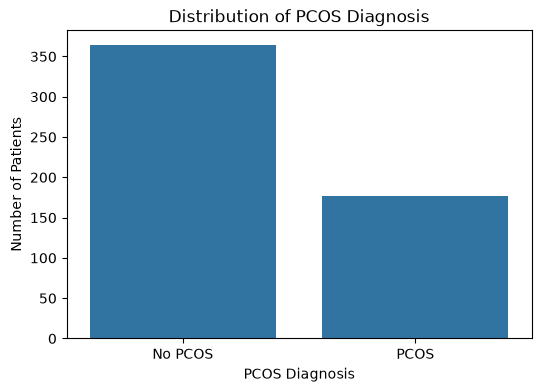

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="PCOS (Y/N)")

plt.title("Distribution of PCOS Diagnosis")
plt.xlabel("PCOS Diagnosis")
plt.ylabel("Number of Patients")

plt.xticks([0,1], ["No PCOS","PCOS"])

plt.show()

### Observation

The dataset contains **541 patient records**, of which **177 patients (32.7%)** were diagnosed with PCOS and **364 patients (67.3%)** were not.

Although the dataset is not perfectly balanced, both classes are well represented, making it suitable for exploratory analysis and predictive modeling.

## Patient Demographics
Age

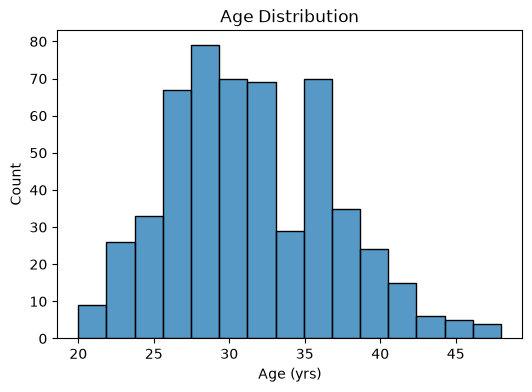

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age (yrs)"], bins=15)

plt.title("Age Distribution")
plt.show()

### Age Distribution Insights

The age distribution shows that most patients in the dataset fall within the **mid-20s to mid-30s age group**, with the highest frequency observed around the late twenties and early thirties.

Since PCOS commonly affects women during their **reproductive years**, this age distribution is clinically relevant and provides an appropriate demographic context for analyzing PCOS-related patterns.

However, the dataset is concentrated around younger age groups, so findings may not fully represent PCOS patterns among adolescents or older women.

In [18]:
# Age Summary Statistics

df["Age (yrs)"].describe()

count    541.000000
mean      31.430684
std        5.411006
min       20.000000
25%       28.000000
50%       31.000000
75%       35.000000
max       48.000000
Name: Age (yrs), dtype: float64

### Age Summary Statistics

The dataset consists of **541 patients** with ages ranging from **20 to 48 years**.

The average patient age is approximately **31.4 years**, while the median age is **31 years**, indicating that the age distribution is relatively balanced without major influence from extreme values.

Around **50% of patients are between 28 and 35 years of age**, highlighting that the dataset predominantly represents women in their early reproductive years.

This demographic distribution aligns with the typical age range in which PCOS symptoms are identified and managed clinically.

### Age Distribution by PCOS Diagnosis

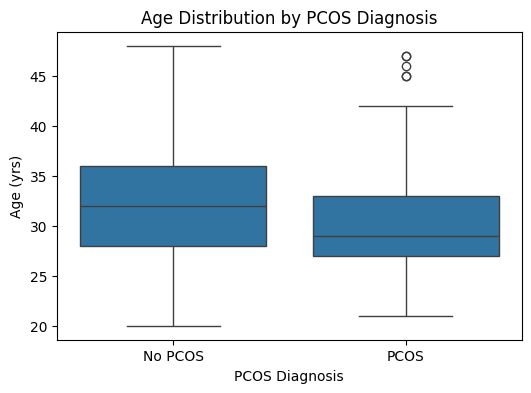

In [5]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x="PCOS (Y/N)", y="Age (yrs)")

plt.xticks([0,1], ["No PCOS", "PCOS"])

plt.title("Age Distribution by PCOS Diagnosis")
plt.xlabel("PCOS Diagnosis")
plt.ylabel("Age (yrs)")

plt.show()

### Observation

The age distributions of patients with and without PCOS show substantial overlap. Patients diagnosed with PCOS have a slightly lower median age than patients without PCOS, although the difference is relatively small.

The spread of ages is comparable across both groups, with a few older patients appearing as outliers in the PCOS group. Overall, age alone does not appear to strongly differentiate patients with and without PCOS in this dataset, suggesting that clinical and hormonal factors are likely to be more informative predictors.

### Weight Distribution

<Axes: xlabel='Weight (Kg)', ylabel='Count'>

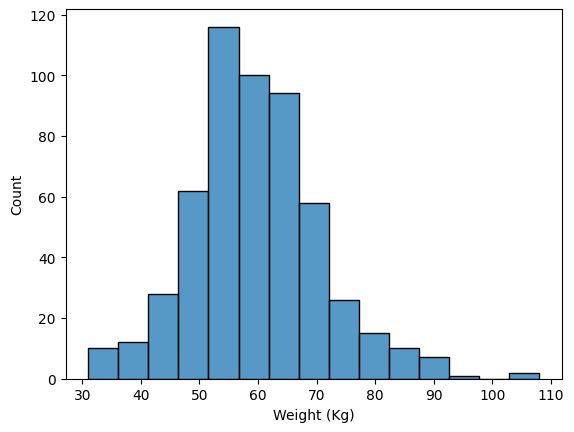

In [6]:
sns.histplot(df["Weight (Kg)"], bins=15)

Most patients have body weights between 50 kg and 70 kg, with the highest concentration around 55–65 kg.

The distribution shows a slight right skew, with a small number of patients having considerably higher body weights. This variation is expected in clinical populations and is reflected more comprehensively through BMI analysis.

### Height Distribution

<Axes: xlabel='Height(Cm)', ylabel='Count'>

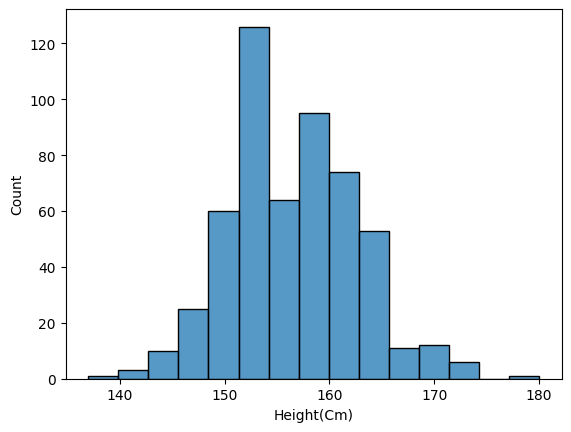

In [7]:
sns.histplot(df["Height(Cm)"], bins=15)

The height distribution is approximately bell-shaped, with most patients having heights between 150 cm and 160 cm.

Only a small number of patients fall at the lower and upper extremes of the distribution, indicating relatively low variability in height across the study population.

Height appears to be normally distributed and primarily serves as a demographic characteristic rather than a direct clinical indicator of PCOS.

## BMI Distribution Analysis

Body Mass Index (BMI) is an important factor in PCOS analysis as it is associated with metabolic health, insulin resistance, and symptom severity.

Understanding the BMI distribution helps identify the overall weight profile of patients and provides context for evaluating lifestyle-related factors in PCOS management.

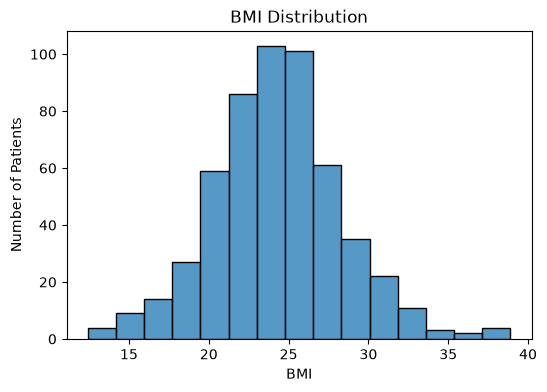

In [19]:
# BMI Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], bins=15)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()

In [20]:
df["BMI"].describe()

count    541.000000
mean      24.311285
std        4.056399
min       12.417882
25%       21.641274
50%       24.238227
75%       26.634958
max       38.900000
Name: BMI, dtype: float64

### BMI Summary Statistics

The dataset contains BMI values for **541 patients**, ranging from **12.4 to 38.9**.

The average BMI is **24.3**, with a median BMI of **24.2**, indicating that the overall patient population is centered around the normal BMI range.

The middle 50% of patients have BMI values between **21.6 and 26.6**, showing that most observations fall within the normal to slightly overweight range.

The BMI distribution shows that while the majority of patients have moderate BMI values, a smaller proportion of patients have higher BMI values, which may be relevant when analyzing metabolic and lifestyle-related factors associated with PCOS.

### BMI Distribution by PCOS Diagnosis

<Axes: xlabel='PCOS (Y/N)', ylabel='BMI'>

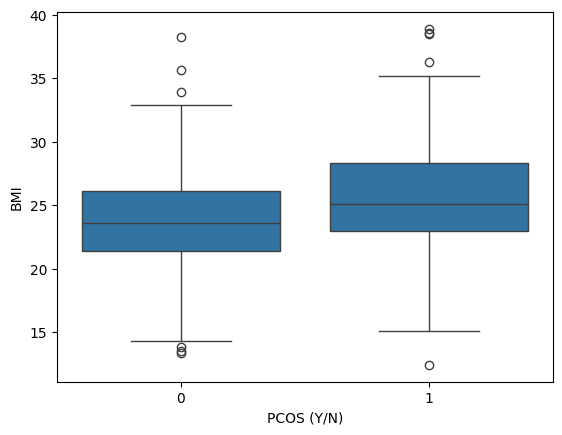

In [8]:
sns.boxplot(data=df,
            x="PCOS (Y/N)",
            y="BMI")

Patients diagnosed with PCOS generally exhibit higher BMI values than those without PCOS. The median BMI is higher in the PCOS group, and the overall distribution is shifted toward larger BMI values.

Although there is considerable overlap between the two groups, patients with PCOS show a wider spread of BMI values and a greater number of higher BMI observations. This suggests that higher BMI is associated with an increased likelihood of PCOS, although BMI alone is not sufficient for diagnosis.

The observed trend is consistent with clinical evidence indicating that overweight and obesity are common metabolic features associated with PCOS, while also highlighting that the condition can occur across a wide range of BMI values.

## Clinical Characteristics

Menstrual Cycle Regularity

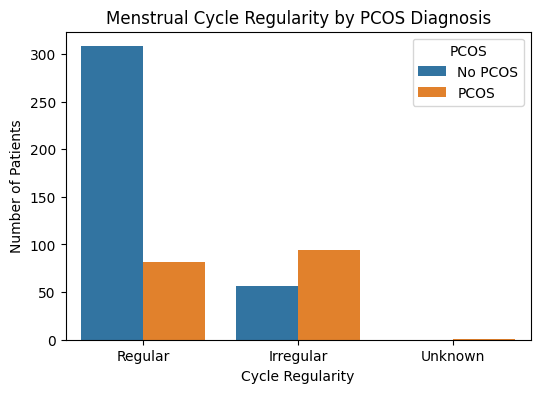

In [ ]:

cycle_map = {2: "Regular", 4: "Irregular", 5: "Unknown"}

df["Cycle Type"] = df["Cycle(R/I)"].map(cycle_map)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Cycle Type",
    hue="PCOS (Y/N)"
)

plt.title("Menstrual Cycle Regularity by PCOS Diagnosis")
plt.xlabel("Cycle Regularity")
plt.ylabel("Number of Patients")

plt.legend(title="PCOS", labels=["No PCOS","PCOS"])

plt.show()

The majority of patients without PCOS reported regular menstrual cycles, whereas irregular menstrual cycles were considerably more common among patients diagnosed with PCOS.

Although a small number of women without PCOS also experienced irregular cycles, the proportion was substantially higher in the PCOS group, indicating a strong association between menstrual irregularity and PCOS diagnosis.

One patient had an uncommon cycle category, which is negligible and does not influence the overall trend.

Cycle Length

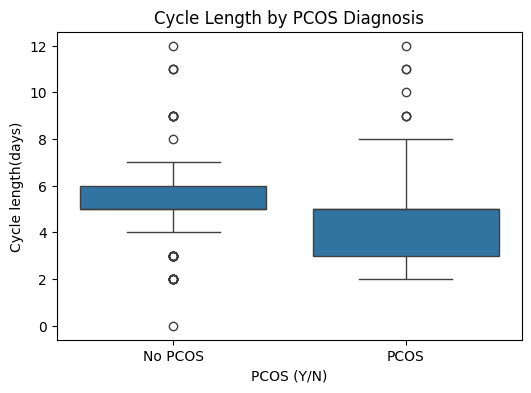

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="PCOS (Y/N)",
    y="Cycle length(days)"
)

plt.xticks([0,1],["No PCOS","PCOS"])

plt.title("Cycle Length by PCOS Diagnosis")

plt.show()

Patients diagnosed with PCOS generally exhibit a wider variation in menstrual cycle length compared to those without PCOS. While the median cycle length is slightly lower in the PCOS group, the broader spread and larger interquartile range indicate greater variability in menstrual patterns among affected patients.

Both groups contain a few outliers with unusually short or long cycle lengths; however, the increased variability observed in the PCOS group is consistent with the hormonal irregularities commonly associated with the condition.

Weight Gain

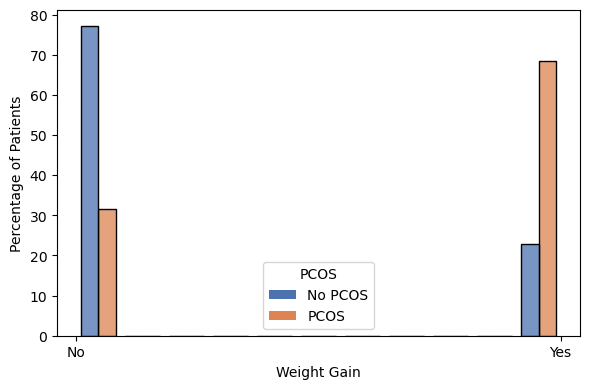

In [11]:
palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS
from matplotlib.patches import Patch

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='Weight gain(Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Weight Gain")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')
plt.tight_layout()
plt.show()

Women diagnosed with PCOS show a substantially higher prevalence of weight gain compared to women without PCOS. Approximately 77% of women with PCOS reported weight gain, whereas only about 32% of women without PCOS reported weight gain. Conversely, the majority of women without PCOS did not report weight gain. This indicates that weight gain is strongly associated with PCOS within this dataset.

Hair Growth

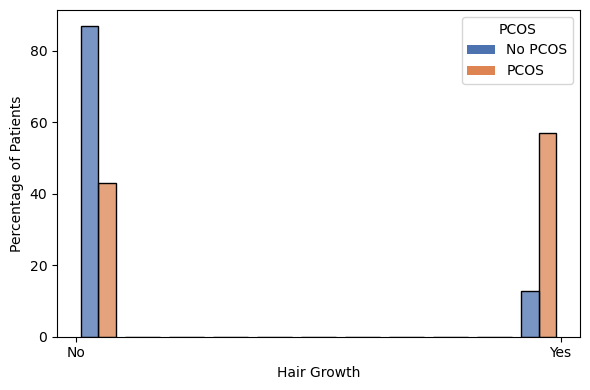

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='hair growth(Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Hair Growth")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')
plt.tight_layout()
plt.show()

Women diagnosed with PCOS were considerably more likely to report excessive hair growth (hirsutism) than women without PCOS. While most women without PCOS did not experience abnormal hair growth, a substantially higher proportion of women with PCOS reported this symptom, indicating a strong association between hirsutism and PCOS in the dataset.

Skin Darkening

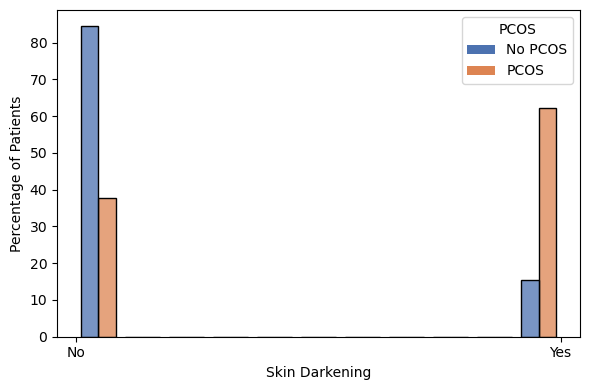

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='Skin darkening (Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Skin Darkening")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')
plt.tight_layout()
plt.show()

Skin darkening was substantially more common among women diagnosed with PCOS than among women without PCOS. A majority of women with PCOS reported experiencing skin darkening, whereas most women without PCOS did not. This suggests a strong association between skin darkening (acanthosis nigricans) and PCOS in the dataset.

Hair Loss

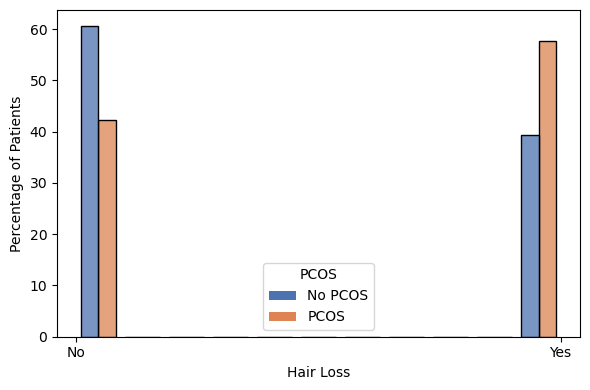

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='Hair loss(Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Hair Loss")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')
plt.tight_layout()
plt.show()

Hair loss was more prevalent among women diagnosed with PCOS than among women without PCOS. While the majority of women without PCOS did not report hair loss, a considerably higher proportion of women with PCOS experienced this symptom. This finding suggests that hair loss is positively associated with PCOS, although the difference is less pronounced than for symptoms such as weight gain, excessive hair growth, and skin darkening.

Pimples

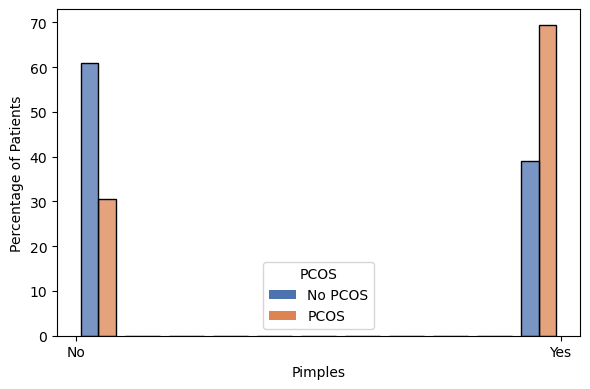

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='Pimples(Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Pimples")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')

plt.tight_layout()
plt.show()

Pimples were more prevalent among women diagnosed with PCOS than among women without PCOS. While acne was observed in both groups, a substantially higher proportion of women with PCOS reported experiencing pimples. This pattern suggests a positive association between pimples and PCOS, consistent with the hormonal imbalances commonly associated with the condition.

Exercise

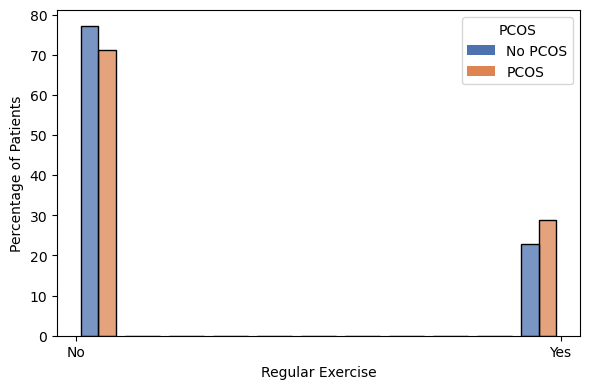

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='Reg.Exercise(Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Regular Exercise")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')

plt.tight_layout()
plt.show()

Most women in both groups reported not exercising regularly. Approximately 77% of women without PCOS and 71% of women with PCOS did not exercise regularly. A slightly higher proportion of women with PCOS reported exercising regularly (≈29%) compared with women without PCOS (≈23%). This suggests that regular exercise alone does not clearly distinguish women with and without PCOS in this dataset.

Fast Food

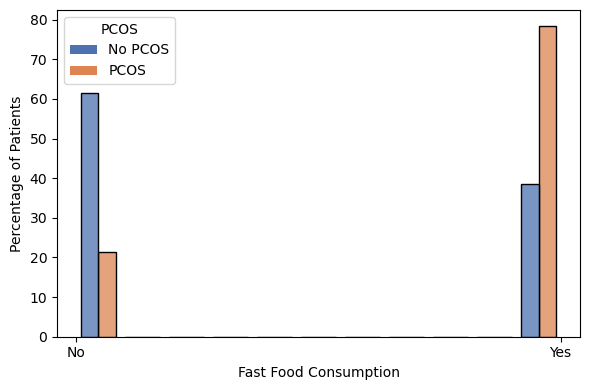

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

plt.figure(figsize=(6,4))

ax = sns.histplot(
    data=df,
    x='Fast food (Y/N)',
    hue='PCOS (Y/N)',
    hue_order=[0,1],
    palette=palette,
    multiple='dodge',
    stat='percent',
    common_norm=False,
    shrink=0.8
)

plt.xticks([0,1], ['No','Yes'])
plt.xlabel("Fast Food Consumption")
plt.ylabel("Percentage of Patients")

legend_elements = [
    Patch(facecolor='#4C72B0', label='No PCOS'),
    Patch(facecolor='#DD8452', label='PCOS')
]

plt.legend(handles=legend_elements, title='PCOS')

plt.tight_layout()
plt.show()

A substantially higher proportion of women with PCOS reported consuming fast food compared with women without PCOS. Approximately 79% of women with PCOS consumed fast food, whereas only 39% of women without PCOS reported doing so. Conversely, the majority of women without PCOS (≈61%) did not consume fast food. This indicates a strong association between fast food consumption and PCOS in this dataset, although the analysis does not establish a causal relationship.

The clinical and lifestyle characteristics reveal several notable differences between women with and without PCOS. Women diagnosed with PCOS were more likely to report weight gain, excessive hair growth (hirsutism), skin darkening, pimples, and frequent fast food consumption. In contrast, regular exercise and hair loss showed comparatively weaker differences between the two groups. Additionally, women with PCOS exhibited greater variability in menstrual cycle length, reflecting the menstrual irregularities commonly associated with the condition. Overall, these findings suggest that clinical symptoms and certain lifestyle factors demonstrate a stronger association with PCOS than demographic characteristics alone.

## Hormonal & Clinical Measurements

Clinical symptoms provide visible indicators of PCOS, but hormonal biomarkers offer deeper insights into the underlying physiological differences between women with and without the condition. The following boxplots compare the distributions of key hormonal and clinical measurements across both groups.

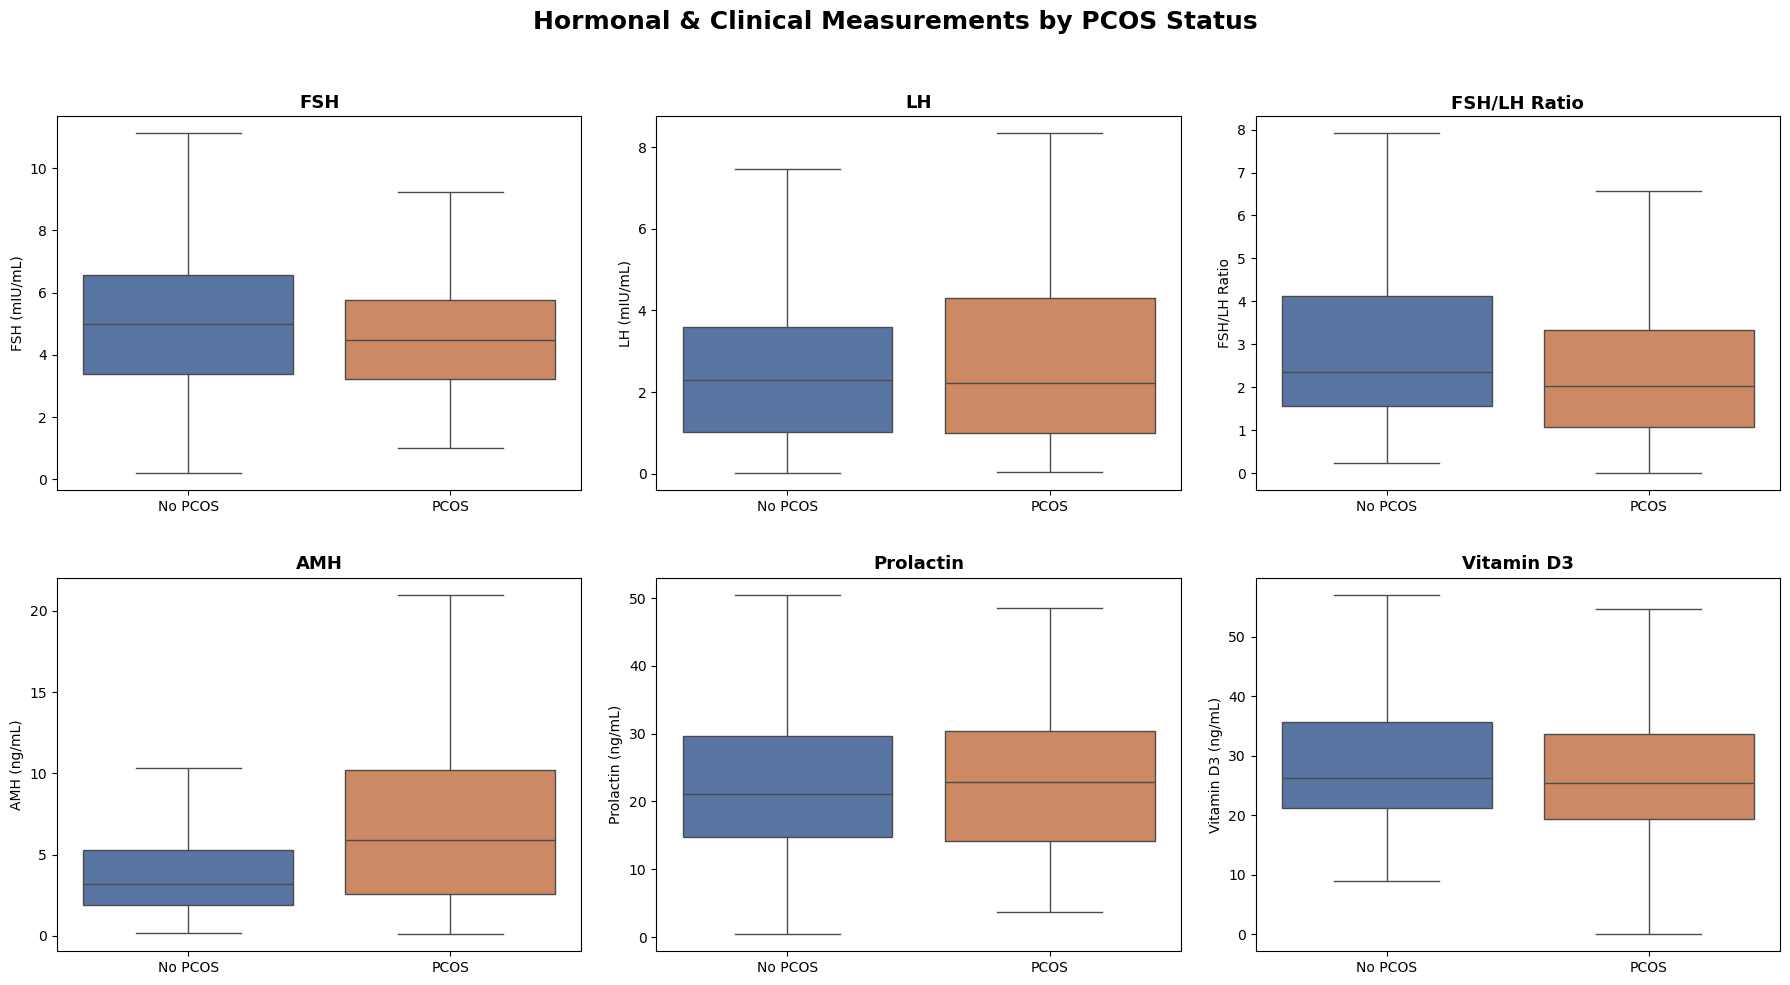

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hormonal and clinical measurement columns
features = [
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'AMH(ng/mL)',
    'PRL(ng/mL)',
    'Vit D3 (ng/mL)'
]

# Titles for display
titles = [
    'FSH',
    'LH',
    'FSH/LH Ratio',
    'AMH',
    'Prolactin',
    'Vitamin D3'
]

# Y-axis labels
ylabels = [
    'FSH (mIU/mL)',
    'LH (mIU/mL)',
    'FSH/LH Ratio',
    'AMH (ng/mL)',
    'Prolactin (ng/mL)',
    'Vitamin D3 (ng/mL)'
]

# Colors
palette = ['#4C72B0', '#DD8452']   # Blue = No PCOS, Orange = PCOS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature, title, ylabel in zip(axes, features, titles, ylabels):

    sns.boxplot(
        data=df,
        x='PCOS (Y/N)',
        y=feature,
        hue='PCOS (Y/N)',
        palette=palette,
        dodge=False,
        showfliers=False,
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No PCOS', 'PCOS'])

plt.suptitle(
    'Hormonal & Clinical Measurements by PCOS Status',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=2)
plt.show()

Hormonal and clinical measurements show noticeable differences between women with and without PCOS, although the strength of these differences varies across biomarkers.

- FSH: The distribution of FSH levels is broadly similar in both groups, with the non-PCOS group showing a slightly higher median. This suggests that FSH alone may not clearly distinguish PCOS status.
- LH: LH levels exhibit a wider spread among women with PCOS, while the median remains comparable between the two groups. This indicates greater variability in LH levels among PCOS patients.
- FSH/LH Ratio: The PCOS group shows a slightly lower median FSH/LH ratio compared to the non-PCOS group, consistent with the hormonal imbalance commonly associated with PCOS.
- AMH: AMH levels are substantially higher in women with PCOS, with both the median and variability exceeding those of the non-PCOS group. This is the clearest difference observed among the hormonal markers.
- Prolactin: Prolactin levels overlap considerably between the two groups, with only a marginally higher median in the PCOS group, suggesting limited discriminatory value.
- Vitamin D3: Vitamin D3 distributions are very similar between the two groups, indicating no strong association with PCOS in this dataset.

Among the hormonal markers analyzed, AMH demonstrates the strongest association with PCOS, while LH and the FSH/LH ratio show moderate differences. In contrast, FSH, prolactin, and Vitamin D3 exhibit substantial overlap between PCOS and non-PCOS patients, indicating that they are less effective as standalone indicators of PCOS.

## Correlation Analysis

Correlation analysis helps identify linear relationships between continuous clinical and hormonal variables. Understanding these relationships can reveal how different patient characteristics and biomarkers vary together, highlight potential redundancies among features, and provide insights for subsequent feature engineering and predictive modeling.

The following heatmap presents the pairwise Pearson correlation coefficients among the continuous variables in the dataset.

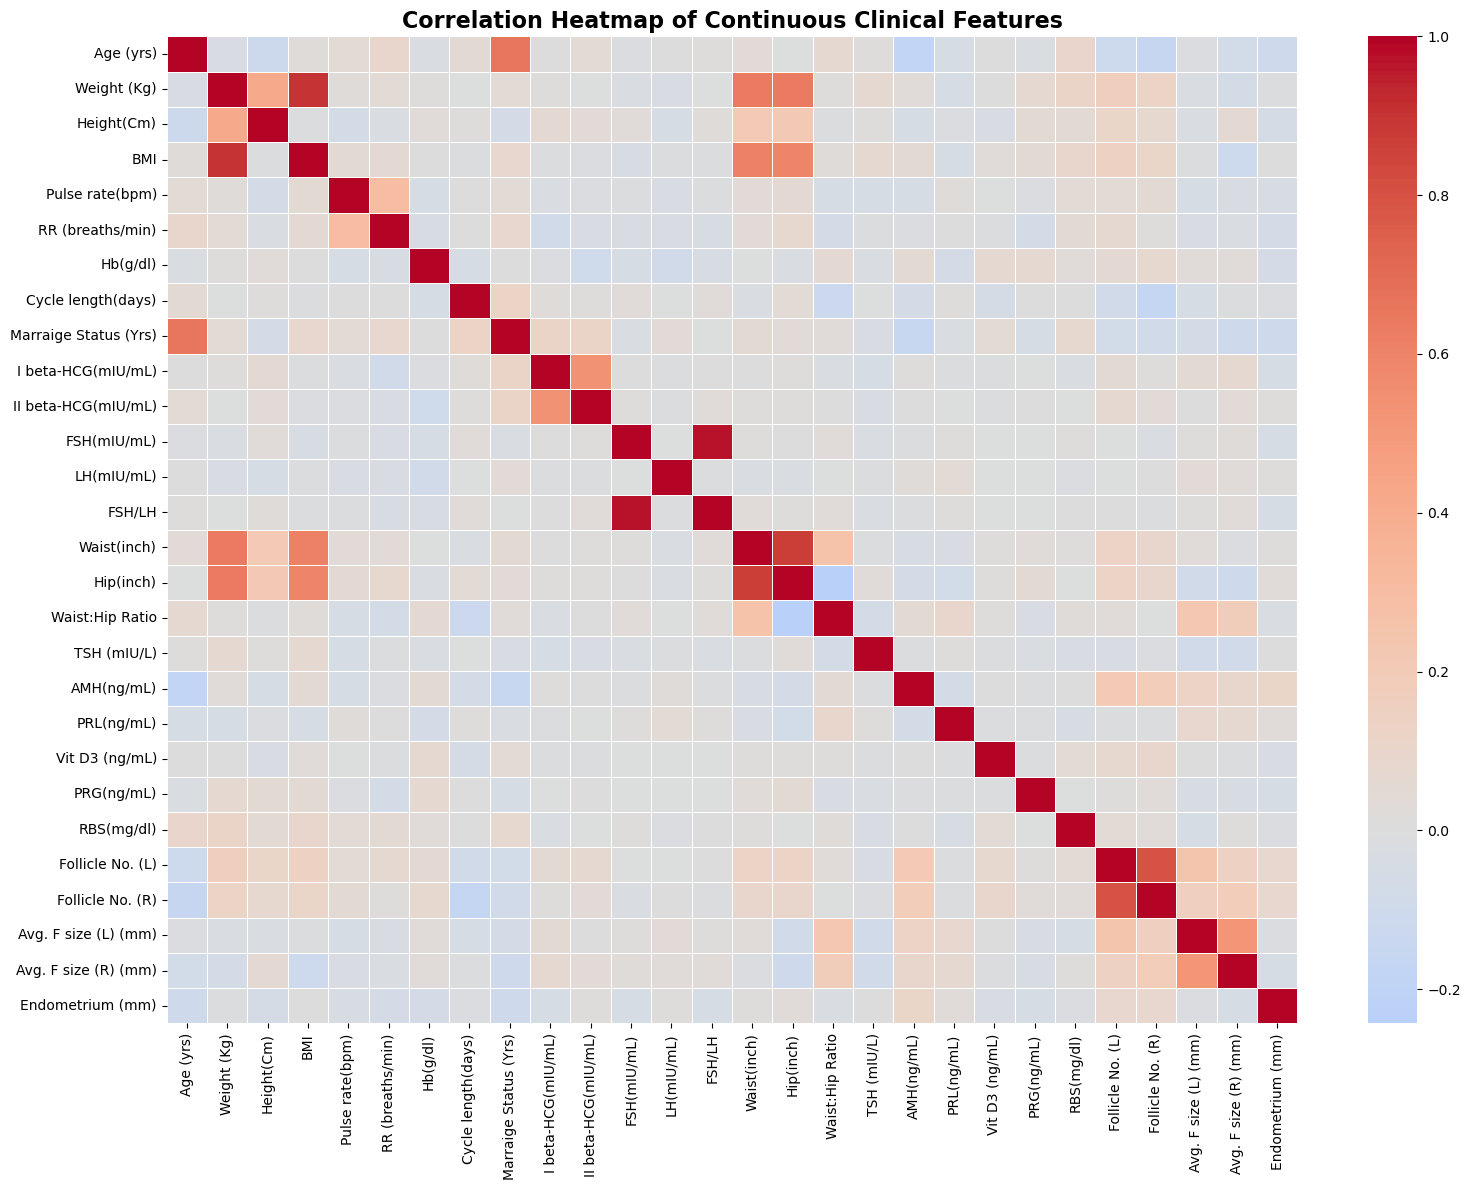

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select continuous numerical features
corr_features = [
    'Age (yrs)',
    'Weight (Kg)',
    'Height(Cm)',
    'BMI',
    'Pulse rate(bpm)',
    'RR (breaths/min)',
    'Hb(g/dl)',
    'Cycle length(days)',
    'Marraige Status (Yrs)',
    'I beta-HCG(mIU/mL)',
    'II beta-HCG(mIU/mL)',
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'Waist(inch)',
    'Hip(inch)',
    'Waist:Hip Ratio',
    'TSH (mIU/L)',
    'AMH(ng/mL)',
    'PRL(ng/mL)',
    'Vit D3 (ng/mL)',
    'PRG(ng/mL)',
    'RBS(mg/dl)',
    'Follicle No. (L)',
    'Follicle No. (R)',
    'Avg. F size (L) (mm)',
    'Avg. F size (R) (mm)',
    'Endometrium (mm)'
]

corr = df[corr_features].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Continuous Clinical Features",
          fontsize=16,
          fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap indicates that most clinical and hormonal variables exhibit weak-to-moderate correlations, suggesting that they provide complementary rather than redundant information.

Several expected relationships are observed:

- Weight, BMI, waist circumference, and hip circumference show strong positive correlations, reflecting their common association with body composition.
- The number of follicles in the left and right ovaries demonstrates a strong positive correlation, indicating consistency between ovarian measurements.
- Average follicle sizes of both ovaries are also positively correlated.
- FSH and the FSH/LH ratio display a strong positive relationship, which is expected since FSH contributes directly to the ratio.
- Most hormonal biomarkers, including LH, prolactin, Vitamin D3, and AMH, show relatively weak correlations with other variables, suggesting that they capture distinct physiological characteristics rather than overlapping information.

Overall, the absence of widespread strong correlations indicates that the dataset contains diverse clinical and hormonal measurements that may each contribute unique information for subsequent predictive modeling.

## Statistical Analysis

While visualizations provide an initial understanding of differences between women with and without PCOS, statistical hypothesis testing is required to determine whether these observed differences are statistically significant.

The Mann–Whitney U test was selected because it compares two independent groups without assuming that the data follow a normal distribution, making it well suited for biomedical variables that often contain skewness and outliers.

The following analysis compares selected clinical and hormonal measurements between the PCOS and non-PCOS groups.

In [18]:
from scipy.stats import mannwhitneyu
import pandas as pd

features = [
    'BMI',
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'FSH/LH',
    'AMH(ng/mL)',
    'PRL(ng/mL)',
    'Vit D3 (ng/mL)'
]

results = []

for feature in features:

    no_pcos = df[df["PCOS (Y/N)"] == 0][feature].dropna()
    pcos = df[df["PCOS (Y/N)"] == 1][feature].dropna()

    stat, p = mannwhitneyu(
        no_pcos,
        pcos,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": round(stat,2),
        "P-value": round(p,5),
        "Significant (p<0.05)": "Yes" if p < 0.05 else "No"
    })

results_df = pd.DataFrame(results)

results_df

,Feature,U Statistic,P-value,Significant (p<0.05)
0,BMI,24438.0,0.00001,Yes
1,FSH(mIU/mL),36781.0,0.00743,Yes
2,LH(mIU/mL),30631.0,0.35357,No
3,FSH/LH,36900.5,0.00601,Yes
4,AMH(ng/mL),22833.0,0.00000,Yes
5,PRL(ng/mL),31300.5,0.59250,No
6,Vit D3 (ng/mL),34262.5,0.22992,No


### Observation

The statistical analysis identified several variables that differ significantly between women with and without PCOS.

- BMI showed a statistically significant difference (p < 0.001), indicating that body mass differs between the two groups.
- AMH demonstrated the strongest statistical significance (p < 0.001), reinforcing its role as one of the most distinctive hormonal markers associated with PCOS.
- FSH and the FSH/LH ratio also showed statistically significant differences (p < 0.05), suggesting measurable hormonal alterations in women with PCOS.
- In contrast, LH, prolactin, and Vitamin D3 did not demonstrate statistically significant differences in this dataset (p > 0.05), indicating that these variables alone may have limited discriminatory power.

Overall, these findings suggest that BMI, AMH, FSH, and the FSH/LH ratio are among the most informative clinical and hormonal measurements distinguishing women with and without PCOS in this dataset.

# Conclusion

This exploratory data analysis examined the demographic, clinical, lifestyle, and hormonal characteristics of women with and without PCOS.

The analysis showed that women diagnosed with PCOS were more likely to exhibit common clinical symptoms such as weight gain, excess hair growth, skin darkening, hair loss, pimples, and higher fast-food consumption. In contrast, regular exercise showed only a modest difference between the two groups.

Hormonal analysis indicated noticeable differences in several biomarkers, particularly Anti-Müllerian Hormone (AMH), while statistical testing confirmed that BMI, AMH, FSH, and the FSH/LH ratio differed significantly between women with and without PCOS. Other variables, including LH, prolactin, and Vitamin D3, did not demonstrate statistically significant differences in this dataset.

Correlation analysis further revealed that most clinical and hormonal variables were only weakly to moderately correlated, suggesting that they capture complementary aspects of the condition rather than redundant information.

Overall, the exploratory analysis identified several informative clinical and hormonal features associated with PCOS and established a strong foundation for feature engineering and predictive modeling in the subsequent notebooks.